## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset Folder Locations

## Environment Setup and Dataset Loading

In [ ]:
train_directory = "/content/drive/My Drive/AI/Traffic_Sign_-2/Train/"
test_directory = "/content/drive/My Drive/AI/Traffic_Sign_-2/Test/"

### Required Package Installation

## Install Packages and Load Dependencies

In [ ]:
!pip install numpy matplotlib seaborn scikit-learn pillow tensorflow

## Import Core Libraries

In [ ]:
import os
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import load_model

import time

### Re-defining Image Processing Parameters, Data Generators, and Models

This section re-initializes the image processing parameters, data generators, and the deeper model architectures that might have been skipped or lost their state during previous executions. This ensures that all necessary components are available for model training and evaluation.

In [ ]:
traffic_image_size = (224, 224) #Target Size for resizing
batch_size = 64
traffic_class_count = 5
traffic_validation_ratio = 0.2 #20% for validation

In [ ]:
traffic_train_datagen = ImageDataGenerator(
    rescale = 1./255, # we're normalizing here from 0 to 1 (range of rgb values 1 to 255)
    rotation_range = 10,
    width_shift_range = 0.05,
    height_shift_range = 0.05,
    zoom_range = 0.05,
    horizontal_flip = True,
    validation_split = traffic_validation_ratio ##20% of the data will be used for validation
)

#data augmentation is performed only for the training dataset

In [ ]:
traffic_train_loader = traffic_train_datagen.flow_from_directory(
    train_directory,
    target_size = traffic_image_size,
    batch_size = batch_size,
    class_mode = 'sparse',
    shuffle = True,
    seed = 123,
    subset = "training"
)

Found 12883 images belonging to 5 classes.


In [ ]:
traffic_validation_loader = traffic_train_datagen.flow_from_directory(
    train_directory,
    target_size = traffic_image_size,
    batch_size = batch_size,
    class_mode = 'sparse',
    shuffle = False,
    seed = 123,
    subset = "validation"
)

Found 3217 images belonging to 5 classes.


In [ ]:
testing_preprocessor = ImageDataGenerator(rescale=1./255)

traffic_test_loader = testing_preprocessor.flow_from_directory(
    test_directory,
    target_size=traffic_image_size,
    batch_size =64,
    class_mode='sparse',
    shuffle=False,
    seed=123
)

Found 0 images belonging to 0 classes.


In [ ]:
input_shape = (224, 224, 3)
traffic_class_count = 5

regularized_sgd_traffic_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005), input_shape=input_shape),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),

    Dense(traffic_class_count, activation='softmax')
])

regularized_sgd_traffic_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 220, 220, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 106, 106, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 49, 49, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 20, 20, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25600)          │             

 Total params: 7,773,221 (29.65 MB)

 Trainable params: 7,770,405 (29.64 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [ ]:
input_shape = (224, 224, 3)
traffic_class_count = 5

deep_adam_traffic_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005), input_shape=input_shape),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),

    Dense(traffic_class_count, activation='softmax')
])

deep_adam_traffic_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 220, 220, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 106, 106, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 49, 49, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 20, 20, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 25600)          │             

 Total params: 7,773,221 (29.65 MB)

 Trainable params: 7,770,405 (29.64 MB)

 Non-trainable params: 2,816 (11.00 KB)

### Helper Function for Class Counts

## Dataset Review and Pre-processing

In [ ]:
def count_images_per_label(directory):
    label_image_counts = {}
    for label_name in os.listdir(directory):
        label_folder = os.path.join(directory, label_name)
        if os.path.isdir(label_folder):
            image_file_list = [f for f in os.listdir(label_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            label_image_counts[label_name] = len(image_file_list)
    return label_image_counts

## Count Images in the Training Set

In [ ]:
training_label_counts = count_images_per_label(train_directory)

## Print Training Image Summary

In [ ]:
training_image_total = 0
validation_image_total = 0
print("Training Images:")
print("Classes:")
for label_title, count in training_label_counts.items():
    training_image_total += count
    print(f"'{label_title}': {count} images")
print()
print(f"Total Training Images Count: {training_image_total}")
print(f"Total Images Count: {training_image_total}")

Training Images:
Classes:
'SpeedLimit': 6688 images
'No Entry': 2938 images
'Crossings': 1828 images
'DIrection': 2968 images
'Cautions': 1678 images

Total Training Images Count: 16100
Total Images Count: 16100


## Create a Holdout Test Split

In [ ]:
import os
import shutil
import random

# Folder setup
source_training_path = '/content/drive/My Drive/AI/Traffic_Sign_-2/Train/'  # Original train folder
train_directory = source_training_path  # You keep the training images here
test_directory = '/content/drive/My Drive/AI/Traffic_Sign_-2/Test/'  # Target test folder

# Create test directories if they don't exist
os.makedirs(test_directory, exist_ok=True)

# Reserve a fixed portion of each class for testing
holdout_ratio = 0.2
random.seed(42)

# Move a sample of images from every label folder
for label_name in os.listdir(source_training_path):
    label_folder = os.path.join(source_training_path, label_name)
    if not os.path.isdir(label_folder):
        continue

    sample_images = os.listdir(label_folder)
    random.shuffle(sample_images)
    split_idx = int(len(sample_images) * (1 - holdout_ratio))

    train_images = sample_images[:split_idx]
    test_images = sample_images[split_idx:]

    # Ensure test class folder exists
    os.makedirs(os.path.join(test_directory, label_name), exist_ok=True)

    # Move test images
    for img in test_images:
        src = os.path.join(label_folder, img)
        dst = os.path.join(test_directory, label_name, img)
        shutil.move(src, dst)

    print(f"{label_name}: {len(train_images)} train / {len(test_images)} test")

SpeedLimit: 5350 train / 1338 test
No Entry: 2350 train / 588 test
Crossings: 1462 train / 366 test
DIrection: 2374 train / 594 test
Cautions: 1342 train / 336 test


## Visualise the Training Class Balance

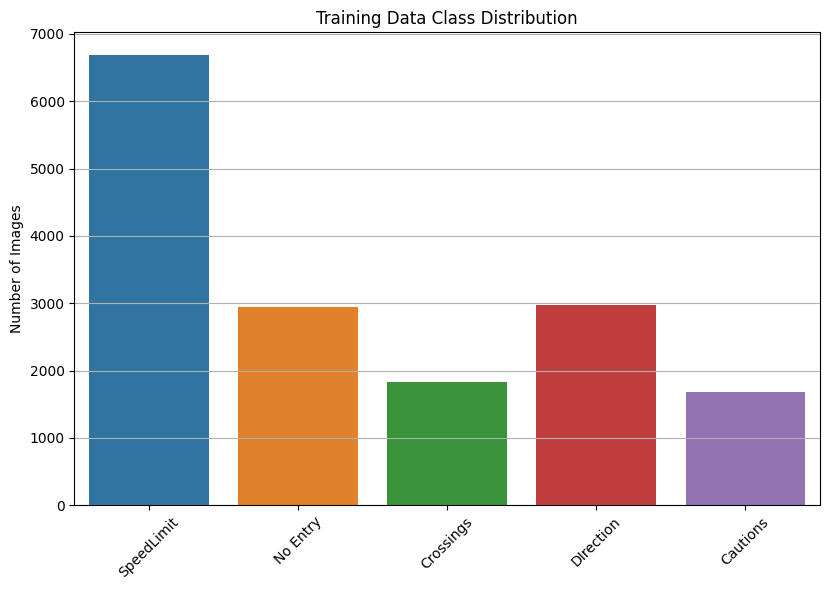

In [ ]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=list(training_label_counts.keys()), y=list(training_label_counts.values()), hue=list(training_label_counts.keys()), legend=False)
plt.title('Training Data Class Distribution')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

## Count Images in the Test Set

In [ ]:
import os

testing_root = "/content/drive/My Drive/AI/Traffic_Sign_-2/Test/"
testing_image_total = sum(
    len(files)
    for label in os.listdir(testing_root)
    if os.path.isdir(os.path.join(testing_root, label))
    for files in [os.listdir(os.path.join(testing_root, label))]
)
print(f"Images in test/: {testing_image_total}")

Images in test/: 0


## Preview Sample Images by Class

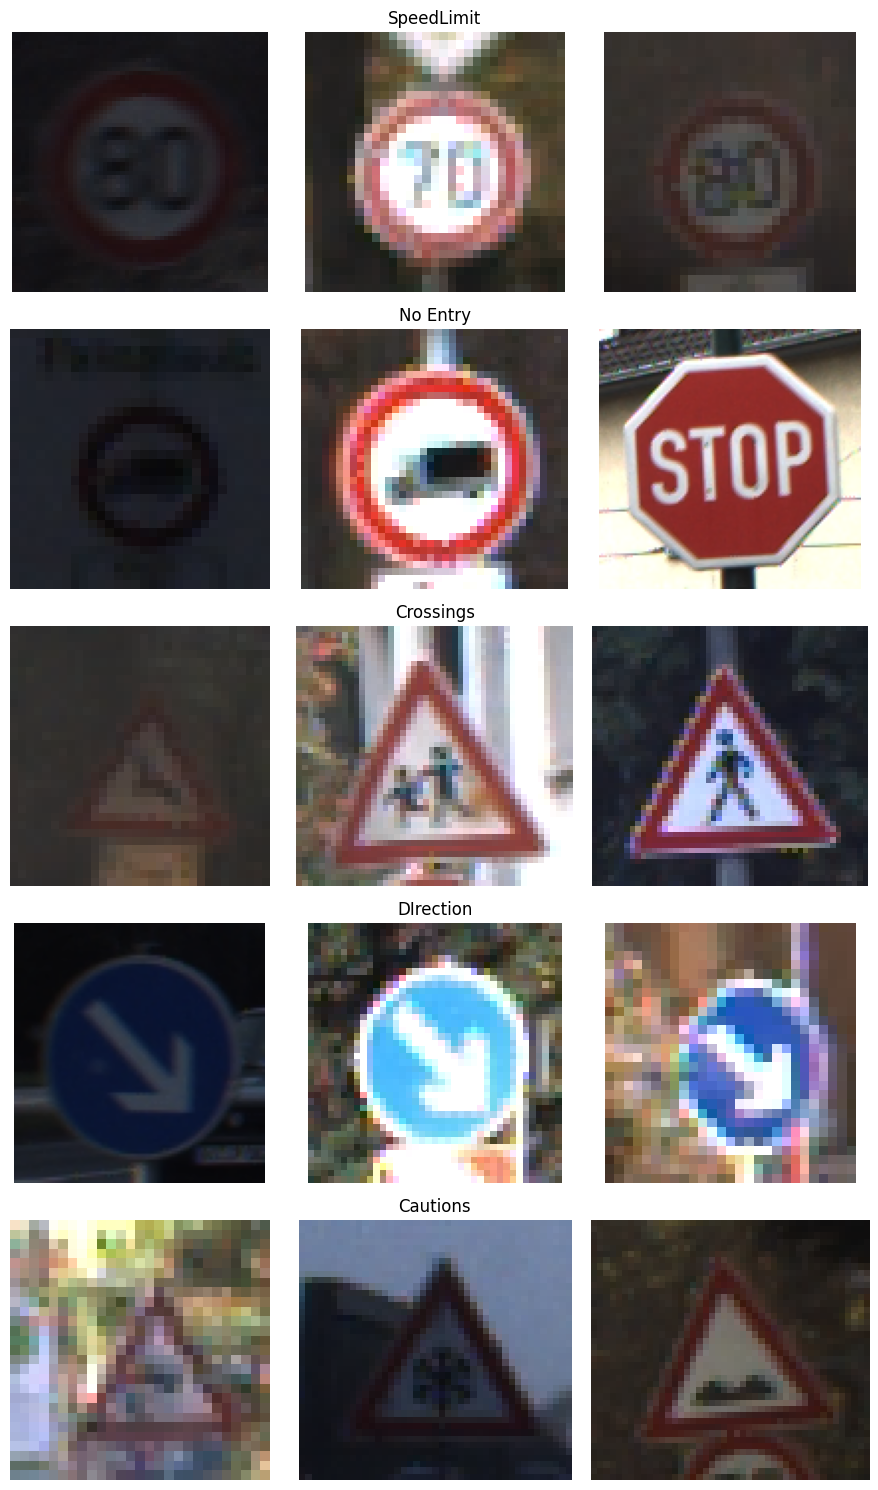

In [ ]:
from PIL import Image, UnidentifiedImageError
import os
import random
import matplotlib.pyplot as plt

train_directory = "/content/drive/My Drive/AI/Traffic_Sign_-2/Train/"
label_lookup = os.listdir(train_directory)

plt.figure(figsize=(3 * 3, len(label_lookup) * 3))

for i, label in enumerate(label_lookup):
    label_path = os.path.join(train_directory, label)
    sample_images = [img for img in os.listdir(label_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    selected_images = random.sample(sample_images, min(3, len(sample_images)))

    for j, image_filename in enumerate(selected_images):
        image_location = os.path.join(label_path, image_filename)
        try:
            image = Image.open(image_location).convert('RGB')
            plt.subplot(len(label_lookup), 3, i * 3 + j + 1)
            plt.imshow(image)
            plt.axis('off')
            if j == 1:
                plt.title(label)
        except UnidentifiedImageError:
            print(f" Skipping unreadable image: {img_path}")

plt.tight_layout()
plt.show()


## Helper Function for Removing Invalid Images

In [ ]:
def delete_unreadable_images(directory):
    removed = 0
    for subdir, _, files in os.walk(directory):
        for file in files:
            file_location = os.path.join(subdir, file)
            try:
                img = Image.open(file_location)
                img.verify()
            except (IOError, SyntaxError) as e:
                print(f"Removing corrupt image: {file_location}. Error: {e}")
                os.remove(file_location)
                removed += 1
    print(f"Total corrupt images removed: {removed}")

## Remove Images That Cannot Be Opened

In [ ]:
delete_unreadable_images(train_directory)
delete_unreadable_images(test_directory)

Removing corrupt image: /content/drive/My Drive/AI/Traffic_Sign_-2/Train/SpeedLimit/00004_00034_00024.png. Error: cannot identify image file '/content/drive/My Drive/AI/Traffic_Sign_-2/Train/SpeedLimit/00004_00034_00024.png'
Removing corrupt image: /content/drive/My Drive/AI/Traffic_Sign_-2/Train/SpeedLimit/00008_00000_00023.png. Error: cannot identify image file '/content/drive/My Drive/AI/Traffic_Sign_-2/Train/SpeedLimit/00008_00000_00023.png'
Removing corrupt image: /content/drive/My Drive/AI/Traffic_Sign_-2/Train/SpeedLimit/00005_00015_00002.png. Error: cannot identify image file '/content/drive/My Drive/AI/Traffic_Sign_-2/Train/SpeedLimit/00005_00015_00002.png'
Removing corrupt image: /content/drive/My Drive/AI/Traffic_Sign_-2/Train/SpeedLimit/00005_00028_00008.png. Error: cannot identify image file '/content/drive/My Drive/AI/Traffic_Sign_-2/Train/SpeedLimit/00005_00028_00008.png'
Removing corrupt image: /content/drive/My Drive/AI/Traffic_Sign_-2/Train/SpeedLimit/00004_00037_0002

## Check Image File Formats

## Image Data Generators and Preprocessing

In [ ]:
import os
from PIL import Image

def detected_formats(label_directory):
    format_total = {}

    for subdir, _, files in os.walk(label_directory):
        for file in files:
            file_location = os.path.join(subdir, file)
            try:
                img = Image.open(file_location)
                file_format = img.format

                if file_format in format_total:
                    format_total[file_format] += 1
                else:
                    format_total[file_format] = 1
            except Exception as e:
                print(f"Error with image {filepath}: {e}")

    return format_total

training_formats = detected_formats(train_directory)
testing_formats = detected_formats(test_directory)
print(training_formats)
print(testing_formats)

{'PNG': 12850}
{'PNG': 3225}


## Analyze Image Sizes

In [ ]:
def summarise_image_dimensions(root_dir):
    image_widths, image_heights = [], []
    sample_count = 0
    for label_folder_name, _, files in os.walk(root_dir):
        for file_name in files:
            if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                path = os.path.join(label_folder_name, file_name)
                try:
                    with Image.open(path) as img:
                        img_width, img_height = img.size
                        image_widths.append(img_width)
                        image_heights.append(img_height)
                    sample_count += 1
                except Exception as e:
                    print(f"Error processing file {fname}: {e}")

    if sample_count == 0:
        print("No images were processed.")
        return np.array([]), np.array([])

    return np.array(image_widths), np.array(image_heights)

img_width, img_height = summarise_image_dimensions(train_directory)

if img_width.size > 0 and img_height.size > 0:
    print(f"Widths:  min={img_width.min()}, max={img_width.max()}, mean={img_width.mean():.1f}")
    print(f"Heights: min={img_height.min()}, max={img_height.max()}, mean={img_height.mean():.1f}")
else:
    print("No valid image sizes were found.")

Widths:  min=25, max=224, mean=48.5
Heights: min=25, max=219, mean=48.6


## Define Image Processing Parameters

In [ ]:
traffic_image_size = (224, 224) #Target Size for resizing
batch_size = 64
traffic_class_count = 5
traffic_validation_ratio = 0.2 #20% for validation

## Configure Training Data Augmentation

In [ ]:
traffic_train_datagen = ImageDataGenerator(
    rescale = 1./255, # we're normalizing here from 0 to 1 (range of rgb values 1 to 255)
    rotation_range = 10,
    width_shift_range = 0.05,
    height_shift_range = 0.05,
    zoom_range = 0.05,
    horizontal_flip = True,
    validation_split = traffic_validation_ratio ##20% of the data will be used for validation
)

#data augmentation is performed only for the training dataset

## Prepare Training Dataset

In [ ]:
traffic_train_loader = traffic_train_datagen.flow_from_directory(
    train_directory,
    target_size = traffic_image_size,
    batch_size = batch_size,
    class_mode = 'sparse',
    shuffle = True,
    seed = 123,
    subset = "training"
)

Found 10282 images belonging to 5 classes.


## Prepare Validation Dataset

In [ ]:
traffic_validation_loader = traffic_train_datagen.flow_from_directory(
    train_directory,
    target_size = traffic_image_size,
    batch_size = batch_size,
    class_mode = 'sparse',
    shuffle = False,
    seed = 123,
    subset = "validation"
)

Found 2568 images belonging to 5 classes.


## Prepare Test Dataset

In [ ]:
testing_preprocessor = ImageDataGenerator(rescale=1./255)

traffic_test_loader = testing_preprocessor.flow_from_directory(
    test_directory,
    target_size=traffic_image_size,
    batch_size =64,
    class_mode='sparse',
    shuffle=False,
    seed=123
)

Found 3215 images belonging to 5 classes.


## Display Class Indices

## Baseline Model Training (SGD)

### Dataset Understanding and Preprocessing

This dataset consists of traffic sign images intended for classification. Combining the training and test sets, the total number of images in the dataset is `5264 (train) + 11866 (test) = 17130`.

**Class Distribution:**
As observed in the 'Training Data Class Distribution' bar plot, the dataset contains 5 distinct classes:
- 'SpeedLimit': 2192 images
- 'DIrection': 969 images
- 'No Entry': 960 images
- 'Cautions': 546 images
- 'Crossings': 597 images

This distribution shows an imbalance, with 'SpeedLimit' being the most frequent class. This imbalance is reflected in both the training and test splits, and will need to be considered during model evaluation.

**Data Splitting:**
The initial dataset was split into an 80/20 train/test ratio *per class* using `original_dataset_dir` as the source for `train_dir` and `test_dir`. This means the `test_dir` contains images that were explicitly moved from the original `Train` directory to serve as the final, unseen test set. Within the `train_dir`, an additional 80/20 split was performed for training and validation sets respectively, using the `validation_split` parameter in `ImageDataGenerator`.

**Image Preprocessing and Augmentation:**
The `ImageDataGenerator` was used for both preprocessing and augmenting the images:
- `rescale=1./255`: Normalizes pixel values from [0, 255] to [0, 1] for better model performance.
- `rotation_range=10`: Randomly rotates images by a maximum of 10 degrees.
- `width_shift_range=0.05`: Randomly shifts image horizontally by up to 5% of its width.
- `height_shift_range=0.05`: Randomly shifts image vertically by up to 5% of its height.
- `zoom_range=0.05`: Randomly zooms into images by up to 5%.
- `horizontal_flip=True`: Randomly flips images horizontally. This is particularly useful for signs that are symmetrical or whose meaning isn't altered by horizontal flipping.

`ImageDataGenerator` prepared three datasets:
- `training_dataset`: Uses `subset="training"` and `shuffle=True` for randomized training batches with augmentation.
- `validation_dataset`: Uses `subset="validation"` and `shuffle=False` to maintain consistent evaluation order on an unaugmented subset of the training data.
- `test_dataset`: Uses a separate `ImageDataGenerator` with only `rescale=1./255` and `shuffle=False` to evaluate the model on the `test_dir` without augmentation.

In [ ]:
traffic_train_loader.class_indices.items()

dict_items([('Cautions', 0), ('Crossings', 1), ('DIrection', 2), ('No Entry', 3), ('SpeedLimit', 4)])

## Visualize Sample Images

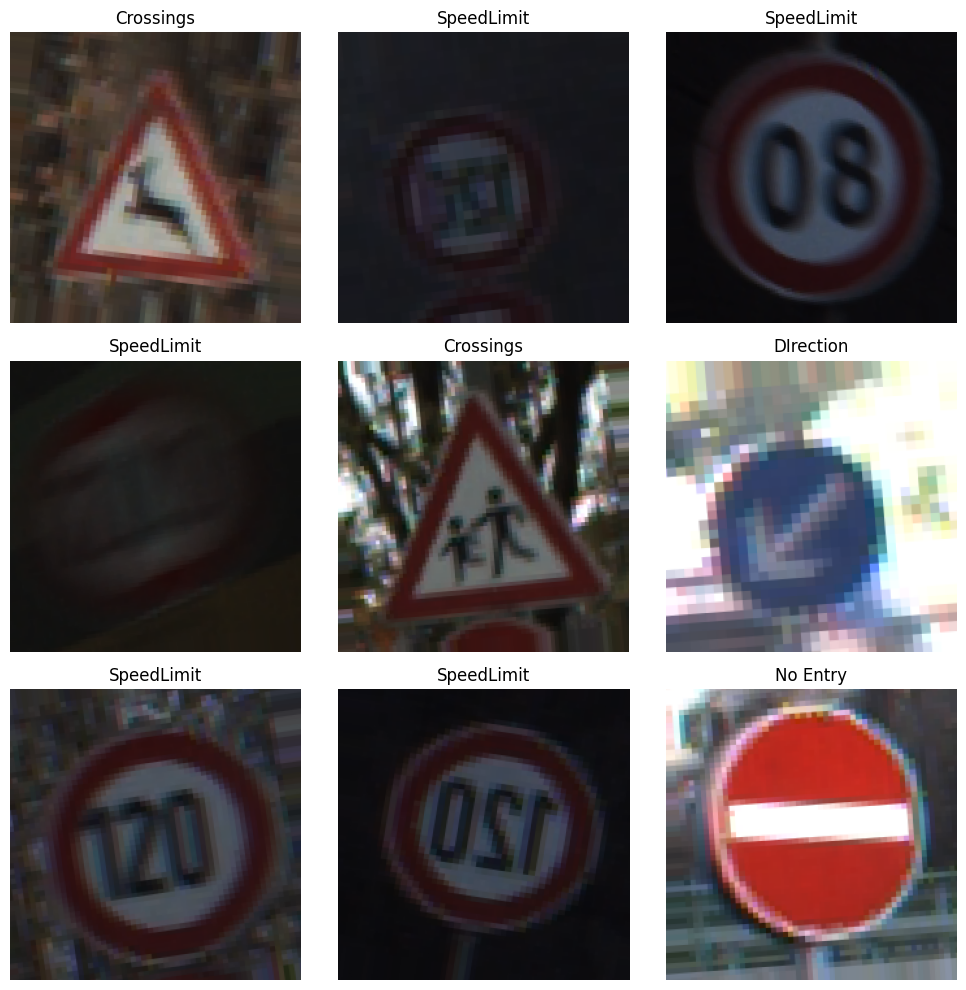

In [ ]:
label_lookup = {}
for label_name, label_id in traffic_train_loader.class_indices.items():
    label_lookup[label_id] = label_name
sample_images, sample_labels = next(traffic_train_loader)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(sample_images[i])
    plt.title(f"{label_lookup[int(sample_labels[i])]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Define Baseline Model Architecture (Direct)

In [ ]:
input_shape = (224, 224, 3)
traffic_class_count = 5
batch_size = 64

baseline_adam_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(traffic_class_count, activation='softmax')
])

baseline_adam_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_80 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,179,461 (42.65 MB)

 Trainable params: 11,179,461 (42.65 MB)

 Non-trainable params: 0 (0.00 B)

## Define Model Builder Function

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

def create_cnn_model():
    cnn_model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(traffic_class_count, activation='softmax')
    ])
    return cnn_model


## Define Common Callbacks

In [111]:
training_callbacks = [
    ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
]


## Train Baseline Model (SGD)

In [ ]:
baseline_sgd_model = create_cnn_model()
baseline_sgd_model.compile(
    optimizer=SGD(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_sgd_history = baseline_sgd_model.fit(
    traffic_train_loader,
    validation_data=traffic_validation_loader,
    epochs=15,
    batch_size=batch_size,
    callbacks=training_callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.4452 - loss: 1.4687 - val_accuracy: 0.5599 - val_loss: 1.3113
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.5167 - loss: 1.2714 - val_accuracy: 0.6235 - val_loss: 1.0439
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.6128 - loss: 1.0586 - val_accuracy: 0.7180 - val_loss: 0.8641
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.7026 - loss: 0.8140 - val_accuracy: 0.7164 - val_loss: 0.7113
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.7447 - loss: 0.6664 - val_accuracy: 0.7416 - val_loss: 0.5668
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.7771 - loss: 0.5706 - val_accuracy: 0.7685 - val_loss: 0.5596
Epoch 7/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.8050 - loss: 0.4955 - val_accuracy: 0.7930 - val_loss: 0.4495
Epoch 8/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.8188 - loss: 0.4500 - val_accuracy: 0.8329 - val_loss

### Train Baseline Model (Adam)

## Baseline Model Training (Adam)

In [ ]:
baseline_adam_model = create_cnn_model()
baseline_adam_model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_adam_history = baseline_adam_model.fit(
    traffic_train_loader,
    validation_data=traffic_validation_loader,
    epochs=15,
    batch_size = batch_size,
    callbacks=training_callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.6952 - loss: 0.7901 - val_accuracy: 0.7922 - val_loss: 0.4089
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.8331 - loss: 0.3693 - val_accuracy: 0.7702 - val_loss: 0.4736
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.8750 - loss: 0.2741 - val_accuracy: 0.8150 - val_loss: 0.4602
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.9178 - loss: 0.2043 - val_accuracy: 0.8256 - val_loss: 0.4572
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.9377 - loss: 0.1546 - val_accuracy: 0.8769 - val_loss: 0.3509
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.9424 - loss: 0.1540 - val_accuracy: 0.8631 - val_loss: 0.3360
Epoch 7/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9575 - loss: 0.1178 - val_accuracy: 0.8753 - val_loss: 0.4025
Epoch 8/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.9656 - loss: 0.0996 - val_accuracy: 0.8566 - val_loss

### Plot SGD Training History

## Deeper Model Training (SGD)

## Evaluate Baseline SGD Model

In [ ]:
# Evaluate the model on the test dataset
baseline_sgd_test_loss, baseline_sgd_test_accuracy = baseline_sgd_model.evaluate(traffic_test_loader)

# Print test results
print(f"Test Loss: {baseline_sgd_test_loss:.4f}")
print(f"Test Accuracy: {baseline_sgd_test_accuracy:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 40s 255ms/step - accuracy: 0.9104 - loss: 0.2218
Test Loss: 0.2218
Test Accuracy: 0.9104


## Classification Report for Baseline SGD Model

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Get true labels (only works if test_dataset is a DirectoryIterator or similar)
true_test_labels = traffic_test_loader.classes

# Predict labels
baseline_prediction_scores = baseline_sgd_model.predict(traffic_test_loader)
predicted_label_ids = np.argmax(baseline_prediction_scores, axis=1)

# Fix class names to only include those that are in y_true
class_label_names = list(traffic_test_loader.class_indices.keys())
observed_label_ids = np.unique(true_test_labels)
observed_class_names = [class_label_names[i] for i in observed_label_ids]

# Print classification report
from sklearn.metrics import classification_report
print(classification_report(true_test_labels, predicted_label_ids, labels=observed_label_ids, target_names=observed_class_names))


156/156 ━━━━━━━━━━━━━━━━━━━━ 42s 268ms/step
              precision    recall  f1-score   support

    Cautions       0.76      0.57      0.65       988
   Crossings       0.67      0.84      0.74      1076
   DIrection       0.99      0.98      0.99      2186
    No Entry       0.92      0.95      0.93      1731
  SpeedLimit       0.97      0.96      0.97      3945

    accuracy                           0.91      9926
   macro avg       0.86      0.86      0.86      9926
weighted avg       0.91      0.91      0.91      9926



## Evaluate Baseline Adam Model

In [ ]:
baseline_adam_test_loss, baseline_adam_test_accuracy = baseline_adam_model.evaluate(traffic_test_loader)

print(f"Test Loss: {baseline_adam_test_loss:.4f}")
print(f"Test Accuracy: {baseline_adam_test_accuracy:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 44s 276ms/step - accuracy: 0.9737 - loss: 0.0915
Test Loss: 0.0915
Test Accuracy: 0.9737


## Classification Report for Baseline Adam Model

In [ ]:
# Get true and predicted labels
true_test_labels = traffic_test_loader.classes
baseline_prediction_scores = baseline_adam_model.predict(traffic_test_loader)
predicted_label_ids = np.argmax(baseline_prediction_scores, axis=1)

# Get all class names from the test dataset
class_label_names = list(traffic_test_loader.class_indices.keys())

# Get only the class indices present in y_true
observed_label_ids = sorted(np.unique(true_test_labels))
observed_class_names = [class_label_names[i] for i in observed_label_ids]

# Print classification report for only present classes
print(classification_report(true_test_labels, predicted_label_ids, labels=observed_label_ids, target_names=observed_class_names))


156/156 ━━━━━━━━━━━━━━━━━━━━ 42s 268ms/step
              precision    recall  f1-score   support

    Cautions       0.89      0.91      0.90       988
   Crossings       0.92      0.89      0.91      1076
   DIrection       1.00      0.99      0.99      2186
    No Entry       0.99      0.99      0.99      1731
  SpeedLimit       0.99      1.00      0.99      3945

    accuracy                           0.97      9926
   macro avg       0.96      0.96      0.96      9926
weighted avg       0.97      0.97      0.97      9926



## Plot Confusion Matrix for Baseline Adam Model

156/156 ━━━━━━━━━━━━━━━━━━━━ 42s 267ms/step


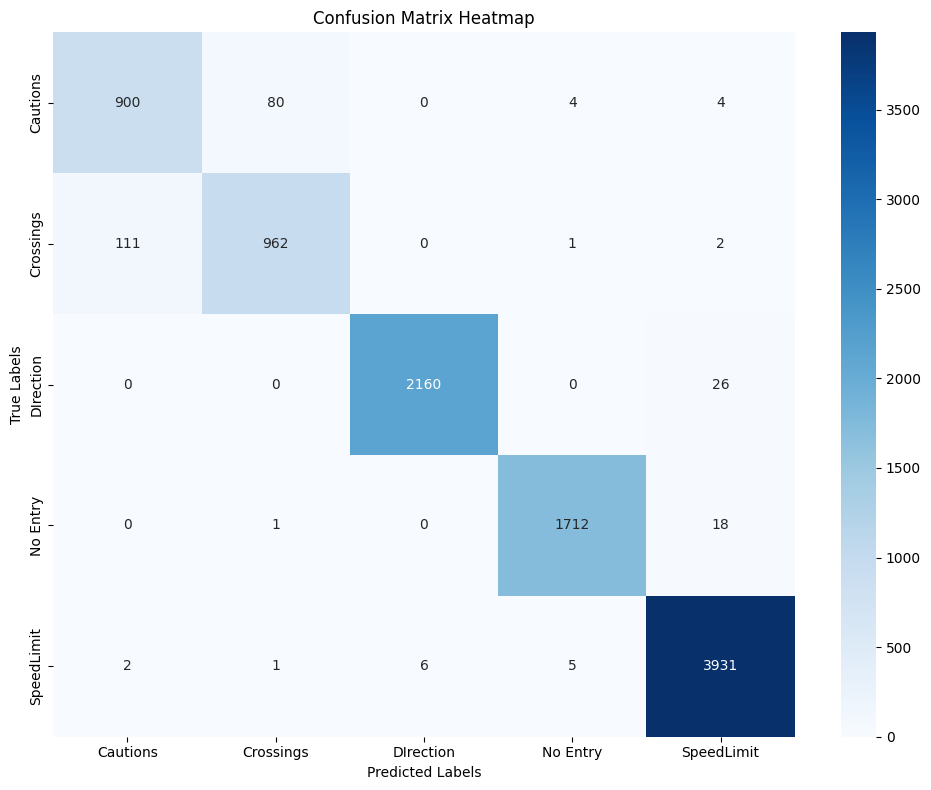

In [ ]:
true_test_labels = traffic_test_loader.classes
baseline_prediction_scores = baseline_adam_model.predict(traffic_test_loader)
predicted_label_ids = np.argmax(baseline_prediction_scores, axis=1)

# Compute confusion matrix
conf_matrix = confusion_matrix(true_test_labels, predicted_label_ids)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=traffic_test_loader.class_indices.keys(),
            yticklabels=traffic_test_loader.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()

## Define Deeper Model Architecture (SGD, L2, Dropout)

In [ ]:
input_shape = (224, 224, 3)
traffic_class_count = 5

regularized_sgd_traffic_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001), input_shape=input_shape),
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(traffic_class_count, activation='softmax')
])

regularized_sgd_traffic_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_72 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 20, 20, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 256)            │     6,553,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,767,589 (29.63 MB)

 Trainable params: 7,767,589 (29.63 MB)

 Non-trainable params: 0 (0.00 B)

## Define Deeper Model Architecture (SGD, L2, BN, Dropout)

In [ ]:
input_shape = (224, 224, 3)
traffic_class_count = 5

regularized_sgd_traffic_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005), input_shape=input_shape),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),

    Dense(traffic_class_count, activation='softmax')
])

regularized_sgd_traffic_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_64 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 220, 220, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 106, 106, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 49, 49, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 20, 20, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 25600)          │             

 Total params: 7,773,221 (29.65 MB)

 Trainable params: 7,770,405 (29.64 MB)

 Non-trainable params: 2,816 (11.00 KB)

## Define Deeper Model Architecture (Adam, L2, BN, Dropout)

In [ ]:
input_shape = (224, 224, 3)
traffic_class_count = 5

deep_adam_traffic_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005), input_shape=input_shape),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),

    Dense(traffic_class_count, activation='softmax')
])

deep_adam_traffic_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_56 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 220, 220, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 106, 106, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 49, 49, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 20, 20, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 25600)          │             

 Total params: 7,773,221 (29.65 MB)

 Trainable params: 7,770,405 (29.64 MB)

 Non-trainable params: 2,816 (11.00 KB)

## Compile Deeper SGD Model (L2, Dropout)

In [109]:
regularized_sgd_traffic_model.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9), #setting the learning rate and the momentum (it helps in faster convergence and controls extreme oscillations)
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Compile Deeper SGD Model (with BN, L2, Dropout)

In [108]:
regularized_sgd_traffic_model.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## Train Deeper SGD Model (L2, Dropout)

In [ ]:
deep_sgd_training_callbacks = [
    ModelCheckpoint("deeper_sgd_model.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)
]

regularized_sgd_history = regularized_sgd_traffic_model.fit(
    traffic_train_loader,
    validation_data=traffic_validation_loader,
    epochs=15,
    callbacks=deep_sgd_training_callbacks
)


Epoch 1/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.6582 - loss: 1.7160 - val_accuracy: 0.1263 - val_loss: 2.6283 - learning_rate: 0.0010
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.8640 - loss: 1.1592 - val_accuracy: 0.1263 - val_loss: 3.2993 - learning_rate: 0.0010
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9173 - loss: 1.0288 - val_accuracy: 0.1524 - val_loss: 3.4685 - learning_rate: 0.0010
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9397 - loss: 0.9577 - val_accuracy: 0.4719 - val_loss: 2.3425 - learning_rate: 0.0010
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.9518 - loss: 0.9308 - val_accuracy: 0.7914 - val_loss: 1.3372 - learning_rate: 0.0010
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.9638 - loss: 0.8965 - val_accuracy: 0.8207 - val_loss: 1.2369 - learning_rate: 0.0010
Epoch 7/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.9676 - loss: 0.8735 - val_accu

## Train Deeper SGD Model (with BN, L2, Dropout)

In [ ]:
regularized_sgd_training_callbacks = [
    ModelCheckpoint("deeper_sgd_model_2.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)
]

regularized_sgd_history = regularized_sgd_traffic_model.fit(
    traffic_train_loader,
    validation_data=traffic_validation_loader,
    epochs=30, # Increased epochs for deeper model training
    callbacks=regularized_sgd_training_callbacks
)


Epoch 1/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.9910 - loss: 0.7987 - val_accuracy: 0.8957 - val_loss: 1.1006 - learning_rate: 5.0000e-04
Epoch 2/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.9927 - loss: 0.7925 - val_accuracy: 0.8989 - val_loss: 1.0737 - learning_rate: 5.0000e-04
Epoch 3/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.9925 - loss: 0.7905 - val_accuracy: 0.9022 - val_loss: 1.0690 - learning_rate: 5.0000e-04
Epoch 4/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.9951 - loss: 0.7868 - val_accuracy: 0.9006 - val_loss: 1.0104 - learning_rate: 5.0000e-04
Epoch 5/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.9929 - loss: 0.7891 - val_accuracy: 0.9006 - val_loss: 1.0942 - learning_rate: 5.0000e-04
Epoch 6/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.9949 - loss: 0.7838 - val_accuracy: 0.9022 - val_loss: 1.0797 - learning_rate: 5.0000e-04
Epoch 7/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.9939 - l

## Compile Deeper Adam Model (with BN, L2, Dropout)

In [106]:
deep_adam_traffic_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## Train Deeper Adam Model (with BN, L2, Dropout)

In [118]:
deep_adam_training_callbacks = [
    ModelCheckpoint(
        "deeper_adam_model.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max"
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )
]

deep_adam_history = deep_adam_traffic_model.fit(
    traffic_train_loader,
    validation_data=traffic_validation_loader,
    epochs=10,
    callbacks=deep_adam_training_callbacks
)

Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.9726 - loss: 0.5803 - val_accuracy: 0.8026 - val_loss: 1.1311 - learning_rate: 0.0010
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.9798 - loss: 0.4656 - val_accuracy: 0.8917 - val_loss: 0.6770 - learning_rate: 0.0010
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.9774 - loss: 0.4433 - val_accuracy: 0.7118 - val_loss: 1.4751 - learning_rate: 0.0010
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.9820 - loss: 0.4251 - val_accuracy: 0.8820 - val_loss: 0.7340 - learning_rate: 0.0010
Epoch 5/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.9948 - loss: 0.2701 - val_accuracy: 0.8968 - val_loss: 0.6463 - learning_rate: 5.0000e-04
Epoch 6/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.9874 - loss: 0.2621 - val_accuracy: 0.9093 - val_loss: 0.4868 - learning_rate: 5.0000e-04
Epoch 7/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.9935 - 

## Evaluate Deeper SGD Model (with BN, L2, Dropout)

In [119]:
regularized_sgd_test_loss, regularized_sgd_test_accuracy = regularized_sgd_traffic_model.evaluate(traffic_test_loader)

print(f"Deeper SGD Model (with BN, L2, Dropout) Test Loss: {regularized_sgd_test_loss:.4f}")
print(f"Deeper SGD Model (with BN, L2, Dropout) Test Accuracy: {regularized_sgd_test_accuracy:.4f}")


51/51 ━━━━━━━━━━━━━━━━━━━━ 12s 243ms/step - accuracy: 0.2012 - loss: 3.1535
Deeper SGD Model (with BN, L2, Dropout) Test Loss: 3.1535
Deeper SGD Model (with BN, L2, Dropout) Test Accuracy: 0.2012


## Classification Report for Deeper SGD Model (with BN, L2, Dropout)

In [84]:
true_test_labels = traffic_test_loader.classes
sgd_prediction_scores = regularized_sgd_traffic_model.predict(traffic_test_loader)
sgd_predicted_labels = np.argmax(sgd_prediction_scores, axis=1)

class_label_names = list(traffic_test_loader.class_indices.keys())
observed_label_ids = sorted(np.unique(true_test_labels))
observed_class_names = [class_label_names[i] for i in observed_label_ids]

print("Classification Report for Deeper SGD Model (with BN, L2, Dropout):")
print(classification_report(true_test_labels, sgd_predicted_labels, labels=observed_label_ids, target_names=observed_class_names))


51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 271ms/step
Classification Report for Deeper SGD Model (with BN, L2, Dropout):
              precision    recall  f1-score   support

    Cautions       0.00      0.00      0.00       332
   Crossings       0.00      0.00      0.00       366
   DIrection       0.07      0.01      0.01       594
    No Entry       0.19      0.98      0.32       587
  SpeedLimit       0.39      0.05      0.09      1336

    accuracy                           0.20      3215
   macro avg       0.13      0.21      0.08      3215
weighted avg       0.21      0.20      0.10      3215



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Plot Deeper Adam Training History (with BN, L2, Dropout)

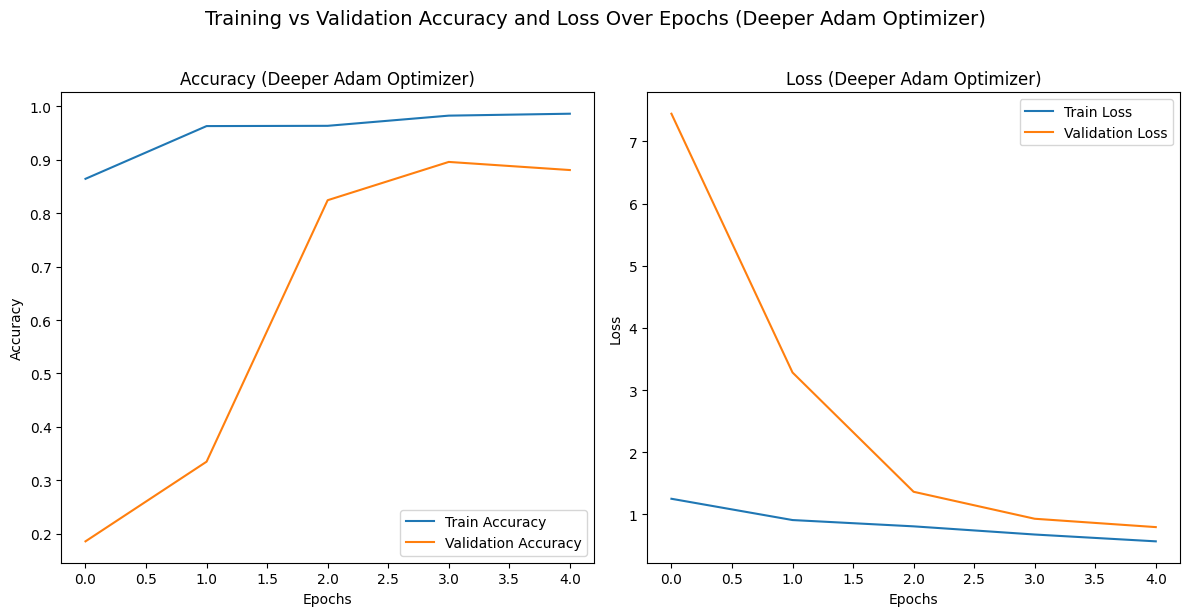

In [114]:
plt.figure(figsize=(12, 6))

# Accuracy subplot
plt.subplot(1, 2, 1)
plt.plot(deep_adam_history.history['accuracy'], label='Train Accuracy')
plt.plot(deep_adam_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy (Deeper Adam Optimizer)')
plt.legend()

# Loss subplot
plt.subplot(1, 2, 2)
plt.plot(deep_adam_history.history['loss'], label='Train Loss')
plt.plot(deep_adam_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss (Deeper Adam Optimizer)')
plt.legend()

plt.suptitle("Training vs Validation Accuracy and Loss Over Epochs (Deeper Adam Optimizer)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Evaluate Deeper Adam Model (with BN, L2, Dropout)

In [115]:
deep_adam_test_loss, deep_adam_test_accuracy = deep_adam_traffic_model.evaluate(traffic_test_loader)

print(f"Deeper Adam Model (with BN, L2, Dropout) Test Loss: {deep_adam_test_loss:.4f}")
print(f"Deeper Adam Model (with BN, L2, Dropout) Test Accuracy: {deep_adam_test_accuracy:.4f}")


51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 280ms/step - accuracy: 0.9596 - loss: 0.6038
Deeper Adam Model (with BN, L2, Dropout) Test Loss: 0.6038
Deeper Adam Model (with BN, L2, Dropout) Test Accuracy: 0.9596


## Classification Report for Deeper Adam Model (with BN, L2, Dropout)

In [87]:
true_test_labels = traffic_test_loader.classes
adam_prediction_scores = deep_adam_traffic_model.predict(traffic_test_loader)
adam_predicted_labels = np.argmax(adam_prediction_scores, axis=1)

class_label_names = list(traffic_test_loader.class_indices.keys())
observed_label_ids = sorted(np.unique(true_test_labels))
observed_class_names = [class_label_names[i] for i in observed_label_ids]

print("Classification Report for Deeper Adam Model (with BN, L2, Dropout):")
print(classification_report(true_test_labels, adam_predicted_labels, labels=observed_label_ids, target_names=observed_class_names))


51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 299ms/step
Classification Report for Deeper Adam Model (with BN, L2, Dropout):
              precision    recall  f1-score   support

    Cautions       0.00      0.00      0.00       332
   Crossings       0.12      0.83      0.21       366
   DIrection       0.00      0.00      0.00       594
    No Entry       0.29      0.34      0.31       587
  SpeedLimit       0.00      0.00      0.00      1336

    accuracy                           0.16      3215
   macro avg       0.08      0.23      0.10      3215
weighted avg       0.07      0.16      0.08      3215



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Ablation Study - Deeper Adam Model (without Batch Normalization)

In [ ]:
input_shape = (224, 224, 3)
traffic_class_count = 5

adam_cnn_without_bn = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005), input_shape=input_shape),
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=l2(0.0005)),

    Dense(traffic_class_count, activation='softmax')
])

adam_cnn_without_bn.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 20, 20, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     6,553,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,767,589 (29.63 MB)

 Trainable params: 7,767,589 (29.63 MB)

 Non-trainable params: 0 (0.00 B)

## Compile and Train Deeper Adam Model (without Batch Normalization)

In [ ]:
adam_cnn_without_bn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

adam_no_bn_training_callbacks = [
    ModelCheckpoint("deep_adam_no_bn_model.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)
]

adam_no_bn_history = adam_cnn_without_bn.fit(
    traffic_train_loader,
    validation_data=traffic_validation_loader,
    epochs=30,
    callbacks=adam_no_bn_training_callbacks
)


## Evaluate Deeper Adam Model (without Batch Normalization)

In [83]:
adam_no_bn_testing_loss, adam_no_bn_testing_accuracy = adam_cnn_without_bn.evaluate(traffic_test_loader)

print(f"Deeper Adam Model (without BN) Test Loss: {adam_no_bn_testing_loss:.4f}")
print(f"Deeper Adam Model (without BN) Test Accuracy: {adam_no_bn_testing_accuracy:.4f}")

51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 264ms/step - accuracy: 0.2149 - loss: 2.3811
Deeper Adam Model (without BN) Test Loss: 2.3811
Deeper Adam Model (without BN) Test Accuracy: 0.2149


## Transfer Learning - MobileNetV2 (Feature Extraction)

In [88]:
# Load the pre-trained MobileNetV2 model
mobilenet_feature_extractor = MobileNetV2(input_shape=input_shape,
                         include_top=False, # Do not include the ImageNet classifier at the top
                         weights='imagenet') # Load weights pre-trained on ImageNet

# Freeze the convolutional base to prevent its weights from being updated during training
mobilenet_feature_extractor.trainable = False

# Create a new model on top
input_tensor = Input(shape=input_shape)
x = mobilenet_feature_extractor(input_tensor, training=False) # Ensure base_model runs in inference mode
x = GlobalAveragePooling2D()(x) # Convert features to a single 1280-element vector per image
x = Dropout(0.2)(x) # Add a dropout layer for regularization
prediction_tensor = Dense(traffic_class_count, activation='softmax')(x) # Add a new classifier layer for our classes

mobilenet_transfer_cnn = Model(input_tensor, prediction_tensor)

mobilenet_transfer_cnn.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Compile and Train Transfer Learning Model (Feature Extraction)

In [89]:
mobilenet_transfer_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_learning_callbacks = [
    ModelCheckpoint("transfer_model_feature_extraction.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)
]

transfer_learning_history = mobilenet_transfer_cnn.fit(
    traffic_train_loader,
    validation_data=traffic_validation_loader,
    epochs=10, # Train for fewer epochs during feature extraction
    callbacks=transfer_learning_callbacks
)


Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.8000 - loss: 0.5172 - val_accuracy: 0.8544 - val_loss: 0.3550 - learning_rate: 0.0010
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.9165 - loss: 0.2261 - val_accuracy: 0.8734 - val_loss: 0.3101 - learning_rate: 0.0010
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.9391 - loss: 0.1734 - val_accuracy: 0.8847 - val_loss: 0.2763 - learning_rate: 0.0010
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.9450 - loss: 0.1474 - val_accuracy: 0.8949 - val_loss: 0.2900 - learning_rate: 0.0010
Epoch 5/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.9534 - loss: 0.1315 - val_accuracy: 0.8972 - val_loss: 0.2434 - learning_rate: 0.0010
Epoch 6/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.9602 - loss: 0.1155 - val_accuracy: 0.8999 - val_loss: 0.2506 - learning_rate: 0.0010
Epoch 7/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.9602 - loss: 0.

## Evaluate Transfer Learning Model (Feature Extraction)

In [91]:
transfer_testing_loss, transfer_testing_accuracy = mobilenet_transfer_cnn.evaluate(traffic_test_loader)

print(f"Transfer Learning Model (Feature Extraction) Test Loss: {transfer_testing_loss:.4f}")
print(f"Transfer Learning Model (Feature Extraction) Test Accuracy: {transfer_testing_accuracy:.4f}")

51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 270ms/step - accuracy: 0.9474 - loss: 0.1379
Transfer Learning Model (Feature Extraction) Test Loss: 0.1379
Transfer Learning Model (Feature Extraction) Test Accuracy: 0.9474


## Transfer Learning - MobileNetV2 (Fine-Tuning)

In [92]:
# Unfreeze the base model
mobilenet_feature_extractor.trainable = True

# Fine-tune from this layer onwards
fine_tune_start_layer = 100 # Unfreeze all layers after a certain point (e.g., after 100 layers)

# Freeze all layers before the `fine_tune_at` layer
for layer in mobilenet_feature_extractor.layers[:fine_tune_start_layer]:
    layer.trainable = False

# Compile the model with a very low learning rate
mobilenet_transfer_cnn.compile(
    optimizer=Adam(learning_rate=0.0001), # Use a lower learning rate for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_transfer_cnn.summary()


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 1,867,845 (7.13 MB)

 Non-trainable params: 396,544 (1.51 MB)

## Train Transfer Learning Model (Fine-Tuning)

In [94]:
fine_tuning_callbacks = [
    ModelCheckpoint(
        "transfer_model_fine_tuning.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max"
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

fine_tuning_history = mobilenet_transfer_cnn.fit(
    traffic_train_loader,
    validation_data=traffic_validation_loader,
    epochs=5,
    callbacks=fine_tuning_callbacks
)

Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.9825 - loss: 0.0505 - val_accuracy: 0.7597 - val_loss: 1.3301 - learning_rate: 1.0000e-04
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.9956 - loss: 0.0138 - val_accuracy: 0.8049 - val_loss: 0.9151 - learning_rate: 1.0000e-04
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.9972 - loss: 0.0078 - val_accuracy: 0.8843 - val_loss: 0.4041 - learning_rate: 1.0000e-04
Epoch 4/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.9973 - loss: 0.0093 - val_accuracy: 0.8956 - val_loss: 0.4417 - learning_rate: 1.0000e-04
Epoch 5/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.9979 - loss: 0.0064 - val_accuracy: 0.8808 - val_loss: 0.7644 - learning_rate: 1.0000e-04


## Evaluate Transfer Learning Model (Fine-Tuning)

In [117]:
fine_tune_testing_loss, fine_tune_testing_accuracy = mobilenet_transfer_cnn.evaluate(traffic_test_loader)

print(f"Transfer Learning Model (Fine-Tuning) Test Loss: {fine_tune_testing_loss:.4f}")
print(f"Transfer Learning Model (Fine-Tuning) Test Accuracy: {fine_tune_testing_accuracy:.4f}")

51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 290ms/step - accuracy: 0.9226 - loss: 0.2791
Transfer Learning Model (Fine-Tuning) Test Loss: 0.2791
Transfer Learning Model (Fine-Tuning) Test Accuracy: 0.9226


## Classification Report for Transfer Learning Model (Fine-Tuning)

In [97]:
true_test_labels = traffic_test_loader.classes
fine_tune_prediction_scores = mobilenet_transfer_cnn.predict(traffic_test_loader)
fine_tune_predicted_labels = np.argmax(fine_tune_prediction_scores, axis=1)

class_label_names = list(traffic_test_loader.class_indices.keys())
observed_label_ids = sorted(np.unique(true_test_labels))
observed_class_names = [class_label_names[i] for i in observed_label_ids]

print("Classification Report for Transfer Learning Model (Fine-Tuning):")
print(classification_report(true_test_labels, fine_tune_predicted_labels, labels=observed_label_ids, target_names=observed_class_names))


51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 348ms/step
Classification Report for Transfer Learning Model (Fine-Tuning):
              precision    recall  f1-score   support

    Cautions       0.77      0.91      0.83       332
   Crossings       0.92      0.74      0.82       366
   DIrection       1.00      0.90      0.95       594
    No Entry       1.00      0.89      0.94       587
  SpeedLimit       0.91      1.00      0.95      1336

    accuracy                           0.92      3215
   macro avg       0.92      0.89      0.90      3215
weighted avg       0.93      0.92      0.92      3215

